# F3 — Improved Models: RF, XGBoost & DistilBERT Fine-Tuning

**Objetivo**: Mejorar la clasificacion de sentimiento sobre el baseline de DistilBERT frozen + LogisticRegression (F3). Se prueban Random Forest, XGBoost sobre embeddings + engineered features, LoRA fine-tuning y full fine-tuning de DistilBERT.

**Metodologia**: Los modelos clasicos se entrenan sobre embeddings congelados de 768d combinados con features del EDA. El fine-tuning entrena DistilBERT directamente para clasificacion de secuencia.

**Salidas**: Tabla comparativa de metricas, graficos, tracking en MLflow, reporte JSON en `reports/`.


## 1. Instalar dependencias

Solo lo que no viene en Colab: `polars` para datos, `mlflow` para tracking, `xgboost` y `peft` para modelos.


In [1]:
!pip install -q mlflow xgboost transformers -U
!pip install -q "torchao>=0.16.0" -U
!pip install -q peft -U


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 74.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 89.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 72.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.3/86.3 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90

In [2]:
import polars as pl
import numpy as np
import torch
import gc
import os
import json
import time
import mlflow
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from transformers import (
    AutoTokenizer, AutoModel, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding,
    EarlyStoppingCallback
)
from peft import LoraConfig, get_peft_model, TaskType
from tqdm.notebook import tqdm


## 2. Montar Google Drive


In [4]:
drive.mount('/content/drive')

DRIVE_BASE = "/content/drive/MyDrive/ML/proyecto_integrador"
DATA_DIR = f"{DRIVE_BASE}/data"
PARQUET_PATH = f"{DATA_DIR}/office_products_balanced.parquet"
EMB_DIR = f"{DRIVE_BASE}/embeddings"
REPORTS_DIR = f"{DRIVE_BASE}/reports"

print(f"Parquet: {PARQUET_PATH}")
print(f"Embs:    {EMB_DIR}")
print(f"Reports: {REPORTS_DIR}")
print('Drive montado correctamente')

for d in [DATA_DIR, EMB_DIR, REPORTS_DIR]:
    os.makedirs(d, exist_ok=True)


Mounted at /content/drive
Parquet: /content/drive/MyDrive/ML/proyecto_integrador/data/office_products_balanced.parquet
Embs:    /content/drive/MyDrive/ML/proyecto_integrador/embeddings
Reports: /content/drive/MyDrive/ML/proyecto_integrador/reports
Drive montado correctamente


## 3. Cargar datos, muestreo y split

Misma estrategia que F3: muestra estratificada de 100k, split 70/15/15.


In [5]:
SAMPLE_SIZE = 200_000
BATCH_SIZE = 256
MAX_LENGTH = 128
RANDOM_STATE = 42

ENG_FEATURES = [
    'mayusculas_count', 'char_total', 'exclamacion_count',
    'interrogacion_count', 'porcentaje_mayusculas',
    'puntuacion_emocional', 'total_tokens', 'unique_types', 'ttr'
]

df = pl.read_parquet(PARQUET_PATH)

dfs = []
for s in [0, 1, 2]:
    sub = df.filter(pl.col('sentiment') == s)
    n = min(SAMPLE_SIZE // 3, sub.shape[0])
    dfs.append(sub.sample(n=n, seed=RANDOM_STATE))

df_sample = pl.concat(dfs).sample(fraction=1.0, seed=RANDOM_STATE)
print(f"Sample: {df_sample.shape}")
print(df_sample['sentiment'].value_counts().sort('sentiment'))

texts = df_sample['text'].to_list()
labels = df_sample['sentiment'].to_numpy()
eng_features = df_sample.select(ENG_FEATURES).to_numpy()

indices = np.arange(len(texts))
train_idx, test_idx, _, _ = train_test_split(
    indices, labels, test_size=0.15, random_state=RANDOM_STATE, stratify=labels
)
train_idx_2, val_idx = train_test_split(
    train_idx, test_size=round(0.15/0.85, 3),
    random_state=RANDOM_STATE, stratify=labels[train_idx]
)

X_train = [texts[i] for i in train_idx_2]
X_val = [texts[i] for i in val_idx]
X_test = [texts[i] for i in test_idx]
y_train = labels[train_idx_2]
y_val = labels[val_idx]
y_test = labels[test_idx]

eng_train = eng_features[train_idx_2]
eng_val = eng_features[val_idx]
eng_test = eng_features[test_idx]

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")


Sample: (199998, 14)
shape: (3, 2)
┌───────────┬───────┐
│ sentiment ┆ count │
│ ---       ┆ ---   │
│ i32       ┆ u32   │
╞═══════════╪═══════╡
│ 0         ┆ 66666 │
│ 1         ┆ 66666 │
│ 2         ┆ 66666 │
└───────────┴───────┘
Train: 140078, Val: 29920, Test: 30000


## 4. Extraer embeddings con DistilBERT (frozen)

Misma funcion que F3. Guardamos en Drive para no re-extraer si se corta la sesion.


In [6]:
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()
print(f"Device: {device}")

def extract_embeddings(texts, model, tokenizer, batch_size=BATCH_SIZE, max_length=MAX_LENGTH):
    all_embeddings = []
    for i in tqdm(range(0, len(texts), batch_size)):
        batch_texts = texts[i:i+batch_size]
        encoded = tokenizer(
            batch_texts, padding=True, truncation=True,
            max_length=max_length, return_tensors='pt'
        ).to(device)
        with torch.no_grad():
            outputs = model(**encoded)
        embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(embeddings)
        del encoded, outputs
        if i % (batch_size * 10) == 0:
            gc.collect()
    return np.vstack(all_embeddings)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Device: cuda


In [7]:
emb_paths = {
    'train': f"{EMB_DIR}/train_embeddings.npy",
    'val': f"{EMB_DIR}/val_embeddings.npy",
    'test': f"{EMB_DIR}/test_embeddings.npy",
}

if all(os.path.exists(p) for p in emb_paths.values()):
    print("Cargando embeddings existentes...")
    X_train_emb = np.load(emb_paths['train'])
    X_val_emb = np.load(emb_paths['val'])
    X_test_emb = np.load(emb_paths['test'])
    print(f"Train: {X_train_emb.shape}, Val: {X_val_emb.shape}, Test: {X_test_emb.shape}")
else:
    print("Extrayendo embeddings TRAIN...")
    X_train_emb = extract_embeddings(X_train, model, tokenizer)
    print(f"Train embeddings: {X_train_emb.shape}")

    print("Extrayendo embeddings VAL...")
    X_val_emb = extract_embeddings(X_val, model, tokenizer)
    print(f"Val embeddings: {X_val_emb.shape}")

    print("Extrayendo embeddings TEST...")
    X_test_emb = extract_embeddings(X_test, model, tokenizer)
    print(f"Test embeddings: {X_test_emb.shape}")

    for k in emb_paths:
        np.save(emb_paths[k], locals()[f'X_{k}_emb'])
    print("Embeddings extraidos y guardados en Drive")


Extrayendo embeddings TRAIN...


  0%|          | 0/548 [00:00<?, ?it/s]

Train embeddings: (140078, 768)
Extrayendo embeddings VAL...


  0%|          | 0/117 [00:00<?, ?it/s]

Val embeddings: (29920, 768)
Extrayendo embeddings TEST...


  0%|          | 0/118 [00:00<?, ?it/s]

Test embeddings: (30000, 768)
Embeddings extraidos y guardados en Drive


## 5. Preparar features combinadas

Normalizamos las engineered features y las concatenamos con los embeddings para los modelos clasicos.


In [8]:
scaler = StandardScaler()
eng_train_scaled = scaler.fit_transform(eng_train)
eng_val_scaled = scaler.transform(eng_val)
eng_test_scaled = scaler.transform(eng_test)

X_train_combined = np.concatenate([X_train_emb, eng_train_scaled], axis=1)
X_val_combined = np.concatenate([X_val_emb, eng_val_scaled], axis=1)
X_test_combined = np.concatenate([X_test_emb, eng_test_scaled], axis=1)

print(f"Combined dims - Train: {X_train_combined.shape}, Val: {X_val_combined.shape}, Test: {X_test_combined.shape}")


Combined dims - Train: (140078, 777), Val: (29920, 777), Test: (30000, 777)


## 6. Random Forest

Grid search chico sobre n_estimators y max_depth.


In [9]:
results = []

def eval_and_record(name, y_true, y_pred, training_time):
    from sklearn.metrics import precision_recall_fscore_support
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1, 2])
    per_class = {
        label: {
            'precision': round(p[i], 4),
            'recall': round(r[i], 4),
            'f1': round(f[i], 4),
        }
        for i, label in enumerate(['Negativo', 'Neutro', 'Positivo'])
    }
    metrics = {
        'model_name': name,
        'f1_macro': round(f1_score(y_true, y_pred, average='macro'), 4),
        'precision_macro': round(precision_score(y_true, y_pred, average='macro'), 4),
        'recall_macro': round(recall_score(y_true, y_pred, average='macro'), 4),
        'accuracy': round(accuracy_score(y_true, y_pred), 4),
        'per_class': per_class,
        'training_time_seconds': round(training_time, 2),
        'confusion_matrix': confusion_matrix(y_true, y_pred).tolist(),
    }
    # Dedup por model_name (re-ejecutar una celda actualiza, no duplica)
    for i, m in enumerate(results):
        if m['model_name'] == name:
            results[i] = metrics
            break
    else:
        results.append(metrics)
    print(f"  {'':>25} {'precision':<10} {'recall':<10} {'f1':<10}")
    for label, scores in per_class.items():
        print(f"  {label:>25} {scores['precision']:<10} {scores['recall']:<10} {scores['f1']:<10}")
    for k in ['f1_macro', 'precision_macro', 'recall_macro', 'accuracy', 'training_time_seconds']:
        print(f"  {k}: {metrics[k]}")

import joblib
MODEL_PATHS = {}


In [10]:
print("=== Random Forest ===")
rf_params = {'n_estimators': [200], 'max_depth': [None], 'min_samples_leaf': [1, 4]}
best_f1 = -1
best_rf = None
best_elapsed = None

for params in ParameterGrid(rf_params):
    start = time.time()
    rf = RandomForestClassifier(**params, random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X_train_combined, y_train)
    elapsed = time.time() - start
    val_pred = rf.predict(X_val_combined)
    f1 = f1_score(y_val, val_pred, average='macro')
    print(f"  params={params} -> val_f1={f1:.4f}, time={elapsed:.1f}s")
    if f1 > best_f1:
        best_f1 = f1
        best_rf = rf
        best_elapsed = elapsed
    else:
        del rf
    gc.collect()

y_pred_rf = best_rf.predict(X_test_combined)
print("Random Forest - Test:")
eval_and_record('Random Forest', y_test, y_pred_rf, best_elapsed)
rf_feature_names = ENG_FEATURES
rf_feat_imp = best_rf.feature_importances_
os.makedirs(f"{DRIVE_BASE}/models", exist_ok=True)
joblib.dump(best_rf, f"{DRIVE_BASE}/models/rf_model.pkl")
MODEL_PATHS['Random Forest'] = f"{DRIVE_BASE}/models/rf_model.pkl"
del best_rf
gc.collect()


=== Random Forest ===
  params={'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200} -> val_f1=0.6330, time=1282.0s
  params={'max_depth': None, 'min_samples_leaf': 4, 'n_estimators': 200} -> val_f1=0.6367, time=1109.6s
Random Forest - Test:
                            precision  recall     f1        
                   Negativo 0.6246     0.6536     0.6388    
                     Neutro 0.5078     0.547      0.5267    
                   Positivo 0.7695     0.6744     0.7188    
  f1_macro: 0.6281
  precision_macro: 0.634
  recall_macro: 0.625
  accuracy: 0.625
  training_time_seconds: 1109.61


0

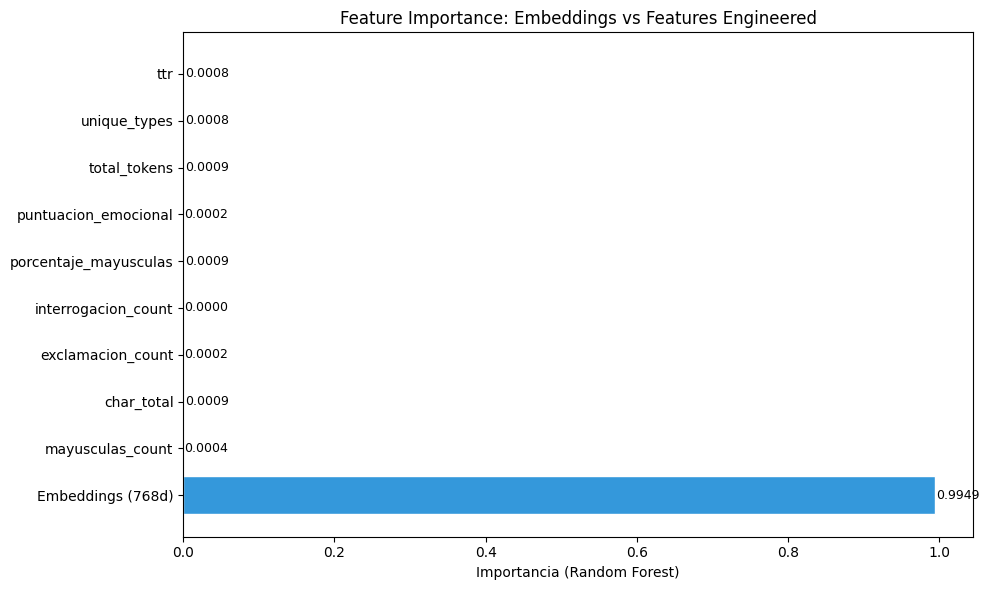

0

In [11]:
plt.figure(figsize=(10, 6))
# Importancia agregada: embeddings (768d) vs engineered features
emb_importance = rf_feat_imp[:768].sum()
eng_importance = rf_feat_imp[768:]

labels = ['Embeddings (768d)'] + list(rf_feature_names)
values = [emb_importance] + [eng_importance[i] for i in range(len(eng_importance))]

colors = ['#3498db'] + ['#2ecc71'] * len(eng_importance)
bars = plt.barh(range(len(values)), values, color=colors, edgecolor='white')
plt.yticks(range(len(values)), labels)
plt.xlabel('Importancia (Random Forest)')
plt.title('Feature Importance: Embeddings vs Features Engineered')
for bar, v in zip(bars, values):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

del rf_feat_imp, rf_feature_names, emb_importance, eng_importance
gc.collect()


## 7. XGBoost

Con early stopping sobre validation set para evitar overfitting.


In [12]:
print("=== XGBoost ===")
xgb_params = {
    'n_estimators': 300,
    'max_depth': 6,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'eval_metric': 'mlogloss',
    'random_state': RANDOM_STATE,
    'early_stopping_rounds': 10,
}

start = time.time()
xgb = XGBClassifier(**xgb_params)
xgb.fit(
    X_train_combined, y_train,
    eval_set=[(X_val_combined, y_val)],
    verbose=False
)
elapsed = time.time() - start
y_pred_xgb = xgb.predict(X_test_combined)
print("XGBoost - Test:")
eval_and_record('XGBoost', y_test, y_pred_xgb, elapsed)
xgb_feature_names = ENG_FEATURES
xgb_feat_imp = xgb.feature_importances_
os.makedirs(f"{DRIVE_BASE}/models", exist_ok=True)
joblib.dump(xgb, f"{DRIVE_BASE}/models/xgb_model.pkl")
MODEL_PATHS['XGBoost'] = f"{DRIVE_BASE}/models/xgb_model.pkl"
del xgb
gc.collect()


=== XGBoost ===
XGBoost - Test:
                            precision  recall     f1        
                   Negativo 0.6583     0.6803     0.6691    
                     Neutro 0.5316     0.5549     0.543     
                   Positivo 0.7772     0.7171     0.7459    
  f1_macro: 0.6527
  precision_macro: 0.6557
  recall_macro: 0.6508
  accuracy: 0.6508
  training_time_seconds: 879.31


73

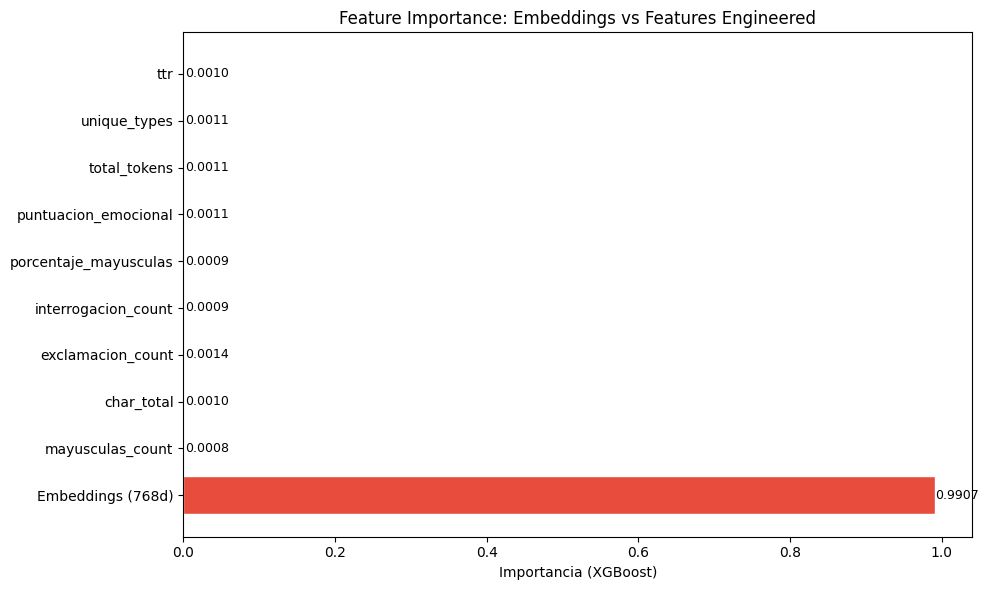

4174

In [13]:
plt.figure(figsize=(10, 6))
emb_importance = xgb_feat_imp[:768].sum()
eng_importance = xgb_feat_imp[768:]

labels = ['Embeddings (768d)'] + list(xgb_feature_names)
values = [emb_importance] + [eng_importance[i] for i in range(len(eng_importance))]

colors = ['#e74c3c'] + ['#f39c12'] * len(eng_importance)
bars = plt.barh(range(len(values)), values, color=colors, edgecolor='white')
plt.yticks(range(len(values)), labels)
plt.xlabel('Importancia (XGBoost)')
plt.title('Feature Importance: Embeddings vs Features Engineered')
for bar, v in zip(bars, values):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

del xgb_feat_imp, xgb_feature_names, emb_importance, eng_importance
gc.collect()


## 8. Fine-tuning DistilBERT

Entrenamos DistilBERT directamente para clasificacion de secuencia. Primero LoRA (param-efficient), luego full fine-tune.


### 8a. Preparar datasets

Tokenizamos y creamos Dataset objects para el Trainer de HuggingFace.


In [14]:
from datasets import Dataset

def tokenize_fn(batch):
    return tokenizer(batch['text'], truncation=True, max_length=MAX_LENGTH)

train_ds = Dataset.from_dict({'text': X_train, 'label': y_train})
val_ds = Dataset.from_dict({'text': X_val, 'label': y_val})
test_ds = Dataset.from_dict({'text': X_test, 'label': y_test})

train_ds = train_ds.map(tokenize_fn, batched=True)
val_ds = val_ds.map(tokenize_fn, batched=True)
test_ds = test_ds.map(tokenize_fn, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        'f1_macro': f1_score(labels, preds, average='macro'),
        'accuracy': accuracy_score(labels, preds),
    }


Map:   0%|          | 0/140078 [00:00<?, ? examples/s]

Map:   0%|          | 0/29920 [00:00<?, ? examples/s]

Map:   0%|          | 0/30000 [00:00<?, ? examples/s]

### 8b. LoRA Fine-Tuning

Congelamos el modelo base y entrenamos adapters LoRA en las capas de atencion.


In [15]:
model_cls = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3
).to(device)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=['q_lin', 'k_lin', 'v_lin', 'out_lin']
)
model_lora = get_peft_model(model_cls, lora_config)
model_lora.print_trainable_parameters()


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 1,182,723 || all params: 68,138,502 || trainable%: 1.7358


In [16]:
lora_args = TrainingArguments(
    output_dir='/content/lora_checkpoints',
    eval_strategy='epoch',
    save_strategy='epoch',
    per_device_train_batch_size=128,
    per_device_eval_batch_size=256,
    num_train_epochs=4,
    learning_rate=2e-4,
    weight_decay=0.01,
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    report_to='none',
)

trainer_lora = Trainer(
    model=model_lora,
    args=lora_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

start = time.time()
trainer_lora.train()
elapsed = time.time() - start

preds_lora = trainer_lora.predict(test_ds)
y_pred_lora = np.argmax(preds_lora.predictions, axis=1)
print("LoRA - Test:")
eval_and_record('DistilBERT + LoRA', y_test, y_pred_lora, elapsed)
lora_log_history = trainer_lora.state.log_history
os.makedirs(f"{DRIVE_BASE}/models", exist_ok=True)
model_lora.save_pretrained(f"{DRIVE_BASE}/models/lora_model")
tokenizer.save_pretrained(f"{DRIVE_BASE}/models/lora_model")
MODEL_PATHS['DistilBERT + LoRA'] = f"{DRIVE_BASE}/models/lora_model"
del model_lora, trainer_lora
gc.collect()
torch.cuda.empty_cache()


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,F1 Macro,Accuracy
1,0.670244,0.639425,0.716014,0.715943
2,0.623377,0.626233,0.723548,0.722794
3,0.604930,0.617175,0.728800,0.727874
4,0.594508,0.616443,0.729505,0.728743


LoRA - Test:
                            precision  recall     f1        
                   Negativo 0.7304     0.7443     0.7373    
                     Neutro 0.6039     0.6189     0.6113    
                   Positivo 0.8406     0.8036     0.8217    
  f1_macro: 0.7234
  precision_macro: 0.7249
  recall_macro: 0.7223
  accuracy: 0.7223
  training_time_seconds: 5331.55


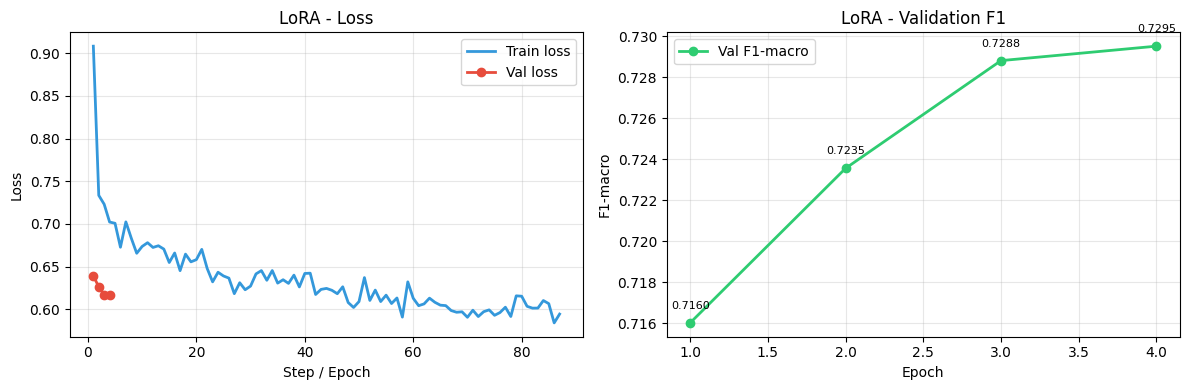

In [17]:
def _plot_learning_curve(log_history, title):
    train_loss = [x['loss'] for x in log_history if 'loss' in x and 'eval_loss' not in x]
    eval_loss = [x['eval_loss'] for x in log_history if 'eval_loss' in x]
    eval_f1 = [x.get('eval_f1_macro', None) for x in log_history if 'eval_loss' in x]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(range(1, len(train_loss) + 1), train_loss,
             label='Train loss', color='#3498db', linewidth=2)
    epochs = list(range(1, len(eval_loss) + 1))
    ax1.plot(epochs, eval_loss, label='Val loss', color='#e74c3c',
             marker='o', linewidth=2)
    ax1.set_xlabel('Step / Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'{title} - Loss')
    ax1.legend()
    ax1.grid(alpha=0.3)

    if eval_f1 and eval_f1[0] is not None:
        ax2.plot(epochs, eval_f1, label='Val F1-macro',
                 color='#2ecc71', marker='o', linewidth=2)
        for e, f in zip(epochs, eval_f1):
            ax2.annotate(f'{f:.4f}', (e, f), textcoords='offset points',
                        xytext=(0, 10), ha='center', fontsize=8)
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('F1-macro')
        ax2.set_title(f'{title} - Validation F1')
        ax2.legend()
        ax2.grid(alpha=0.3)
    else:
        ax2.set_visible(False)

    plt.tight_layout()
    plt.show()



_plot_learning_curve(lora_log_history, 'LoRA')
del lora_log_history


### 8c. Full Fine-Tune

Entrenamos todos los parametros de DistilBERT. Tarda ~3-4 horas en T4. Saltar si no hay tiempo.


In [18]:
model_full = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3
).to(device)

full_args = TrainingArguments(
    output_dir='/content/full_checkpoints',
    eval_strategy='epoch',
    save_strategy='epoch',
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=6,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    report_to='none',
)

trainer_full = Trainer(
    model=model_full,
    args=full_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

start = time.time()
trainer_full.train()
elapsed = time.time() - start

preds_full = trainer_full.predict(test_ds)
y_pred_full = np.argmax(preds_full.predictions, axis=1)
print("Full Fine-Tune - Test:")
eval_and_record('DistilBERT + Full FT', y_test, y_pred_full, elapsed)
full_log_history = trainer_full.state.log_history
os.makedirs(f"{DRIVE_BASE}/models", exist_ok=True)
model_full.save_pretrained(f"{DRIVE_BASE}/models/full_ft_model")
tokenizer.save_pretrained(f"{DRIVE_BASE}/models/full_ft_model")
MODEL_PATHS['DistilBERT + Full FT'] = f"{DRIVE_BASE}/models/full_ft_model"
del model_full, trainer_full
gc.collect()
torch.cuda.empty_cache()


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,F1 Macro,Accuracy
1,0.616067,0.615538,0.727440,0.729011
2,0.557127,0.606530,0.732789,0.733857
3,0.476184,0.635008,0.735317,0.732520
4,0.414875,0.701098,0.725190,0.724699
5,0.342179,0.750917,0.720203,0.720087


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Full Fine-Tune - Test:
                            precision  recall     f1        
                   Negativo 0.7574     0.7103     0.7331    
                     Neutro 0.6002     0.6675     0.6321    
                   Positivo 0.8509     0.8084     0.8291    
  f1_macro: 0.7314
  precision_macro: 0.7362
  recall_macro: 0.7287
  accuracy: 0.7287
  training_time_seconds: 8158.4


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

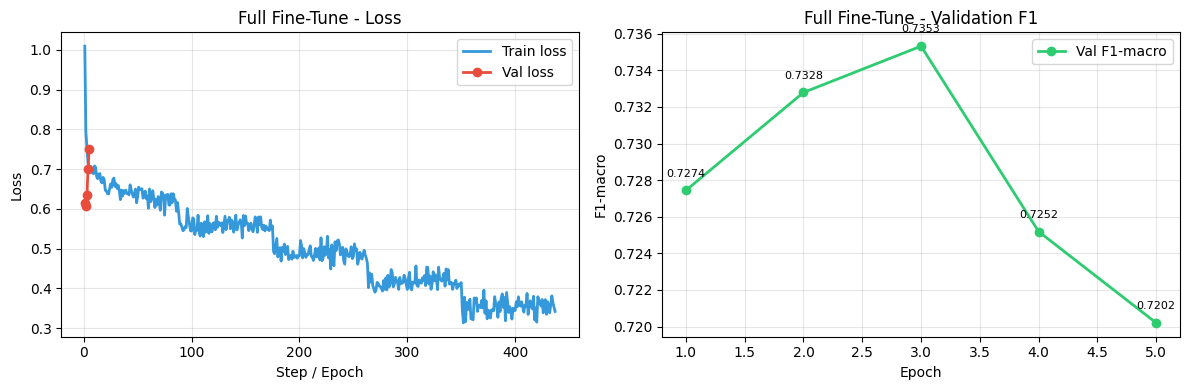

7532

In [19]:
_plot_learning_curve(full_log_history, 'Full Fine-Tune')
del full_log_history, _plot_learning_curve
gc.collect()


### 8d. BERT-base + LoRA


In [ ]:
print("\n" + "="*60)
print("BERT-base + LoRA")
print("="*60)
BERT_NAME = "bert-base-uncased"
bert_tokenizer = AutoTokenizer.from_pretrained(BERT_NAME)
bert_model_seq = AutoModelForSequenceClassification.from_pretrained(BERT_NAME, num_labels=3).to(device)

def bert_tokenize_fn(batch):
    return bert_tokenizer(batch['text'], truncation=True, max_length=MAX_LENGTH)

bert_train_ds = Dataset.from_dict({'text': X_train, 'label': y_train}).map(bert_tokenize_fn, batched=True)
bert_val_ds = Dataset.from_dict({'text': X_val, 'label': y_val}).map(bert_tokenize_fn, batched=True)
bert_test_ds = Dataset.from_dict({'text': X_test, 'label': y_test}).map(bert_tokenize_fn, batched=True)
bert_collator = DataCollatorWithPadding(tokenizer=bert_tokenizer)

lora_bert = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=16, lora_alpha=32, lora_dropout=0.1,
    target_modules=["query", "key", "value", "output.dense"]
)
model_bert_lora = get_peft_model(bert_model_seq, lora_bert)
model_bert_lora.print_trainable_parameters()

bert_args = TrainingArguments(
    output_dir='/content/bert_lora_checkpoints',
    eval_strategy='epoch', save_strategy='epoch',
    per_device_train_batch_size=64, per_device_eval_batch_size=128,
    num_train_epochs=4, learning_rate=1e-4, weight_decay=0.01,
    logging_steps=50, load_best_model_at_end=True,
    metric_for_best_model='f1_macro', report_to='none',
)

trainer_bert = Trainer(
    model=model_bert_lora, args=bert_args,
    train_dataset=bert_train_ds, eval_dataset=bert_val_ds,
    processing_class=bert_tokenizer, data_collator=bert_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

start = time.time()
trainer_bert.train()
elapsed = time.time() - start

preds_bert = trainer_bert.predict(bert_test_ds)
y_pred_bert_lora = np.argmax(preds_bert.predictions, axis=1)
print("BERT-base + LoRA - Test:")
eval_and_record('BERT-base + LoRA', y_test, y_pred_bert_lora, elapsed)
del bert_model_seq, trainer_bert
gc.collect()
torch.cuda.empty_cache()



BERT-base + LoRA


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

Map:   0%|          | 0/140078 [00:00<?, ? examples/s]

Map:   0%|          | 0/29920 [00:00<?, ? examples/s]

Map:   0%|          | 0/30000 [00:00<?, ? examples/s]

trainable params: 1,919,235 || all params: 111,403,782 || trainable%: 1.7228


Epoch,Training Loss,Validation Loss,F1 Macro,Accuracy
1,0.627507,0.636575,0.718679,0.720120
2,0.618212,0.609952,0.729581,0.728108


### 8e. RoBERTa-base + LoRA


In [ ]:
print("\n" + "="*60)
print("RoBERTa-base + LoRA")
print("="*60)
ROBERTA_NAME = "roberta-base"
roberta_tokenizer = AutoTokenizer.from_pretrained(ROBERTA_NAME)
roberta_model_seq = AutoModelForSequenceClassification.from_pretrained(ROBERTA_NAME, num_labels=3).to(device)

def roberta_tokenize_fn(batch):
    return roberta_tokenizer(batch['text'], truncation=True, max_length=MAX_LENGTH)

roberta_train_ds = Dataset.from_dict({'text': X_train, 'label': y_train}).map(roberta_tokenize_fn, batched=True)
roberta_val_ds = Dataset.from_dict({'text': X_val, 'label': y_val}).map(roberta_tokenize_fn, batched=True)
roberta_test_ds = Dataset.from_dict({'text': X_test, 'label': y_test}).map(roberta_tokenize_fn, batched=True)
roberta_collator = DataCollatorWithPadding(tokenizer=roberta_tokenizer)

lora_roberta = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=16, lora_alpha=32, lora_dropout=0.1,
    target_modules=["query", "key", "value", "output.dense"]
)
model_roberta_lora = get_peft_model(roberta_model_seq, lora_roberta)
model_roberta_lora.print_trainable_parameters()

roberta_args = TrainingArguments(
    output_dir='/content/roberta_lora_checkpoints',
    eval_strategy='epoch', save_strategy='epoch',
    per_device_train_batch_size=64, per_device_eval_batch_size=128,
    num_train_epochs=4, learning_rate=1e-4, weight_decay=0.01,
    logging_steps=50, load_best_model_at_end=True,
    metric_for_best_model='f1_macro', report_to='none',
)

trainer_roberta = Trainer(
    model=model_roberta_lora, args=roberta_args,
    train_dataset=roberta_train_ds, eval_dataset=roberta_val_ds,
    processing_class=roberta_tokenizer, data_collator=roberta_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

start = time.time()
trainer_roberta.train()
elapsed = time.time() - start

preds_roberta = trainer_roberta.predict(roberta_test_ds)
y_pred_roberta_lora = np.argmax(preds_roberta.predictions, axis=1)
print("RoBERTa-base + LoRA - Test:")
eval_and_record('RoBERTa-base + LoRA', y_test, y_pred_roberta_lora, elapsed)
del roberta_model_seq, trainer_roberta
gc.collect()
torch.cuda.empty_cache()


### 8f. Ensemble ponderado


In [ ]:
print("\n" + "="*60)
print("Ensemble ponderado")
print("="*60)

# Collect all model predictions (in scope from previous cells)
model_preds = {
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb,
    'DistilBERT + LoRA': y_pred_lora,
    'DistilBERT + Full FT': y_pred_full,
    'BERT-base + LoRA': y_pred_bert_lora,
    'RoBERTa-base + LoRA': y_pred_roberta_lora,
}

# Weighted majority vote using F1 scores as weights
weights_list = []
preds_list = []
for r in results:
    if r['model_name'] in model_preds:
        weights_list.append(r['f1_macro'])
        preds_list.append(model_preds[r['model_name']])

weights_list = np.array(weights_list)
weights_list /= weights_list.sum()

preds_stack = np.array(preds_list)
y_pred_ensemble = np.zeros(len(y_test), dtype=int)
for i in range(len(y_test)):
    weighted_votes = np.zeros(3)
    for j, pred in enumerate(preds_list):
        weighted_votes[pred[i]] += weights_list[j]
    y_pred_ensemble[i] = np.argmax(weighted_votes)

eval_and_record('Ensemble (ponderado)', y_test, y_pred_ensemble, 0.0)
print("\nComposicion del ensemble:")
for r in results:
    if r['model_name'] in model_preds:
        print(f"  {r['model_name']:<30} weight={weights_list[list(model_preds.keys()).index(r['model_name'])]:.4f}")


### 8g. Limpieza de memoria


In [ ]:
print("Liberando memoria...")
for obj in ['bert_model_seq', 'model_bert_lora', 'trainer_bert',
            'bert_train_ds', 'bert_val_ds', 'bert_test_ds',
            'roberta_model_seq', 'model_roberta_lora', 'trainer_roberta',
            'roberta_train_ds', 'roberta_val_ds', 'roberta_test_ds',
            'preds_bert', 'preds_roberta']:
    if obj in dir():
        try: del globals()[obj]
        except: pass
gc.collect()
torch.cuda.empty_cache()
print("OK")


## 9. Resultados comparativos

Graficos comparando todos los modelos: F1-macro, matrices de confusion.


In [ ]:
model_names = [r['model_name'] for r in results]
f1_scores = [r['f1_macro'] for r in results]
class_labels = ['Negativo', 'Neutro', 'Positivo']

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12']
bars = plt.barh(range(len(results)), f1_scores, color=colors[:len(results)])
plt.yticks(range(len(results)), model_names)
plt.xlabel('F1-macro')
plt.title('Comparacion de Modelos - F1-macro')
plt.xlim(0, 1)
for bar, val in zip(bars, f1_scores):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=10)

n_models = len(results)
n_cols = min(3, n_models)
n_rows = (n_models + n_cols - 1) // n_cols

for i, r in enumerate(results):
    plt.subplot(n_rows, n_cols, i + 1)
    cm = np.array(r['confusion_matrix'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels, cbar=False)
    plt.title(r['model_name'].split('+')[0].strip() if '+' in r['model_name'] else r['model_name'])
    plt.xlabel('Predicho')
    plt.ylabel('Real')

plt.tight_layout()
plt.show()


In [ ]:
if not results:
    raise RuntimeError(
        "No hay resultados. Ejecuta primero las celdas de modelos: "
        "RF (celda 15), XGBoost (celda 17), LoRA (celda 22), Full FT (celda 25)"
    )

print(f"{'Modelo':<40} {'F1-macro':<10} {'Precision':<10} {'Recall':<10} {'Accuracy':<10} {'F1-Neg':<10} {'F1-Neu':<10} {'F1-Pos':<10} {'Tiempo(s)':<10}")
print('-' * 130)
for r in results:
    pc = r['per_class']
    print(f"{r['model_name']:<40} {r['f1_macro']:<10} {r['precision_macro']:<10} {r['recall_macro']:<10} {r['accuracy']:<10} {pc['Negativo']['f1']:<10} {pc['Neutro']['f1']:<10} {pc['Positivo']['f1']:<10} {r['training_time_seconds']:<10}")


## 10. MLflow Tracking

Registramos todos los modelos en MLflow para tener el historial completo.


In [ ]:
# Configurar tracking URI de MLflow
# Prioridad: 1) variable de entorno, 2) placeholder manual, 3) fallback SQLite
import os
MLFLOW_TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI", "https://xxxx.ngrok-free.app")

import requests
try:
    r = requests.get(f"{MLFLOW_TRACKING_URI}/api/2.0/mlflow/experiments/list", timeout=5)
    mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
    print(f"MLflow server OK via {MLFLOW_TRACKING_URI}")
except Exception as e:
    print(f"MLflow server no disponible: {e}")
    print("Fallback a SQLite local en Colab...")
    mlflow.set_tracking_uri(f"sqlite:///{DRIVE_BASE}/mlflow_fallback.db")
    MLFLOW_TRACKING_URI = f"sqlite:///{DRIVE_BASE}/mlflow_fallback.db"


In [ ]:
mlflow.set_experiment("distilbert_improved")

best_f1 = max(r['f1_macro'] for r in results)

for r in results:
    with mlflow.start_run(run_name=r['model_name']):
        mlflow.log_params({
            'model_name': r['model_name'],
            'sample_size': SAMPLE_SIZE,
            'batch_size': BATCH_SIZE,
            'max_length': MAX_LENGTH,
            'n_engineered_features': len(ENG_FEATURES),
        })
        per_class_metrics = {}
        for label, scores in r['per_class'].items():
            per_class_metrics[f'f1_{label.lower()}'] = scores['f1']
            per_class_metrics[f'precision_{label.lower()}'] = scores['precision']
            per_class_metrics[f'recall_{label.lower()}'] = scores['recall']
        mlflow.log_metrics({
            'f1_macro': r['f1_macro'],
            'precision_macro': r['precision_macro'],
            'recall_macro': r['recall_macro'],
            'accuracy': r['accuracy'],
            'training_time_seconds': r['training_time_seconds'],
            **per_class_metrics,
        })
        mlflow.log_dict(r['confusion_matrix'], 'confusion_matrix.json')
        model_name_key = r['model_name']
        if model_name_key in MODEL_PATHS and os.path.exists(MODEL_PATHS[model_name_key]):
            mlflow.log_param('model_path', MODEL_PATHS[model_name_key])
        if r['f1_macro'] == best_f1:
            mlflow.set_tag('best_model', 'true')

print(f"MLflow runs en: {MLFLOW_TRACKING_URI}")


## 11. Exportar resultados

Exportamos metricas comparativas a JSON en reports/.


In [ ]:
os.makedirs(REPORTS_DIR, exist_ok=True)

# Dedup final por si alguna celda no uso eval_and_record
seen = {}
for r in results:
    name = r['model_name']
    if name not in seen or r['f1_macro'] > seen[name]['f1_macro']:
        seen[name] = r
deduped = list(seen.values())

export = {
    'baseline': 'DistilBERT frozen + LogisticRegression',
    'improved_results': [
        {k: v for k, v in r.items() if k != 'confusion_matrix'}
        for r in deduped
    ],
    'engineered_features': ENG_FEATURES,
    'sample_size': SAMPLE_SIZE,
    'best_model': max(deduped, key=lambda r: r['f1_macro']),
}

report_path = f"{REPORTS_DIR}/metrics_distilbert_improved.json"
with open(report_path, 'w') as f:
    json.dump(export, f, indent=2)
print(f"Exportado: {report_path}")


In [ ]:
del df, df_sample, model, tokenizer
del X_train_emb, X_val_emb, X_test_emb, y_train, y_val, y_test
del X_train_combined, X_val_combined, X_test_combined
del eng_train, eng_val, eng_test, eng_train_scaled, eng_val_scaled, eng_test_scaled
del texts, labels, eng_features, scaler
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Memoria liberada")
